# **Bike Sharing**
****

## **Contents**

1. Business Problem Understanding
2. Data Understanding
3. Data Preprocessing
4. Modeling
5. Conclusion
6. Recommendation

<br>

****

## **1. Business Problem Understanding**

### **Context**

Bike-sharing systems are a new generation of traditional bike rentals where the whole process, from membership, rental, and return back, has become automatic. Through these systems, a user can easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousand bicycles. Today, great interest exists in these systems due to their important role in traffic, environmental, and health issues.<br><br>


Apart from interesting real-world applications of bike-sharing systems, the characteristics of data generated by these systems make them attractive for research. Unlike other transport services such as buses or subways, the duration of travel, departure, and arrival position is explicitly recorded in these systems. This feature turns the bike-sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that the most important events in the city could be detected by monitoring these data.


### **Problem Statements**

One of the challenges in Bike-sharing systems is the Allocation of Bikes. The company at the very least must be able to provide sufficient amount of bikes to meet the demands of the user. At best, a prediction on how many bikes that should be allocated would help in maintaining the efficiency of operating costs and risk minimalization (stolen bikes, damages from weather etc.).
<br>

Failure to meet the quantity demands of the user might lead to the users losing trust in the company and switch to another mode of transportation or a rival company.

### **Goals**

Based on the problem stated above, The company would stand to benefit from a tool that helps predict the amount of bikes that should be allocated to meet the demands of the users based on existing conditions and historical data.
<br>
<br>
A model capable of learning patterns based on historical data and able to predict the amount of bikes that is needed for each conditions (hours, seasons, weather, etc.) would be the goal of this project.

### **Analytic Approach**

An exploration and examination on data collected will help in determining what data would be the features and it's relation to the target outcome. Based on a Exploratory Data Analysis (EDA), a Regression machine learning model can be defined, trained and tested before the model can be used to predict the target based on the features needed.

### **Metric Evaluation**

Metric Evaluations in Regression Models commonly operates on the principle of $$ Error = Actual Value - Predicted Value $$
Common metric evaluations used in Regression Models include:

- RMSE (Root Mean Squared Error)

    - Measures the average error of the model’s predictions.
    - Penalizes large errors more than small ones because errors are squared before averaging.
    - Lower RMSE = Better model.

- MAE (Mean Absolute Error)

    - Measures the average absolute difference between predicted and actual values.
    - Treats all errors equally (no squaring).
    - Lower MAE = Better model.

- MAPE (Mean Absolute Percentage Error)

    - Measures the percentage error on average.
    - Helps understand how big the errors are relative to actual values.
    - Lower MAPE = Better model, but it struggles with zero or very small actual values.

- R-squared (R², Coefficient of Determination)

    - Measures how well the model explains the variance in the target variable.
    - Ranges from 0 to 1 (higher is better).
    - R² of 0.9 means 90% of the variation in the target is explained by the model.

For this project, all 4 will be used with an emphasis on MAE and MAPE to determine algorithm and parameters used to find the most accurate model

****
## **2. Data Understanding**

- The dataset is a record of bike rentals in the company system from 2011-2012.
- Each row of data represents information related to the time of rental, weather, and corresponding season.

**Attributes Information**

| **Attribute** | **Data Type** | **Description** |
| --- | --- | --- |
| dteday | Object | Date |
| hum | Float | Normalized humidity (the values are divided to 100)|
| weathersit | Integer | 1: Clear, Few clouds, Partly cloudy, Partly cloudy<br> 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br> 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br> 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog |
| holiday | Integer | 0: Not holiday<br> 1: Holiday |
| season | Integer | 1: Winter<br> 2: Spring<br> 3: Summer<br> 4: Fall |
| atemp | Float | "Feels like" temperature in Celsius |
| temp | Float | Normalized temperature in Celsius |
| hr | Integer | Hour (0 to 23) |
| casual | Integer | Count of casual users |
| registered | Integer | Count of registered users |
| cnt | Integer | Count of total rental bikes including both casual and registered users|

### **Load Dataset**

In [51]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [52]:
# Load dataset
df = pd.read_csv('data_bike_sharing.csv')
df

,dteday,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt
0,2011-12-09,0.62,1,0,4,0.3485,0.36,16,24,226,250
1,2012-06-17,0.64,1,0,2,0.5152,0.54,4,2,16,18
2,2011-06-15,0.53,1,0,2,0.6212,0.62,23,17,90,107
3,2012-03-31,0.87,2,0,2,0.3485,0.36,8,19,126,145
4,2012-07-31,0.55,1,0,3,0.6970,0.76,18,99,758,857
...,...,...,...,...,...,...,...,...,...,...,...
12160,2012-01-25,0.75,1,0,1,0.2273,0.24,7,14,243,257
12161,2012-07-06,0.62,1,0,3,0.7424,0.78,0,39,63,102
12162,2012-02-20,0.60,2,1,1,0.2121,0.24,5,0,6,6
12163,2012-03-31,0.77,2,0,2,0.4242,0.42,2,14,55,69


In [53]:
# unique data in columns
listItem = []
for col in df.columns :
    listItem.append( [col, df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)])

tabel1Desc = pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'],
                     data=listItem)
tabel1Desc

,Column Name,Number of Unique,Unique Sample
0,dteday,731,"[2012-08-05, 2011-06-19]"
1,hum,89,"[0.2, 0.22]"
2,weathersit,4,"[4, 1]"
3,holiday,2,"[0, 1]"
4,season,4,"[3, 2]"
5,atemp,65,"[0.8485, 0.5152]"
6,temp,50,"[0.96, 0.06]"
7,hr,24,"[19, 8]"
8,casual,305,"[143, 125]"
9,registered,742,"[319, 623]"


### **Exploratory Data Analysis**

##### **Distribution of Count**

Text(0.5, 0, 'Total Rented Bikes')

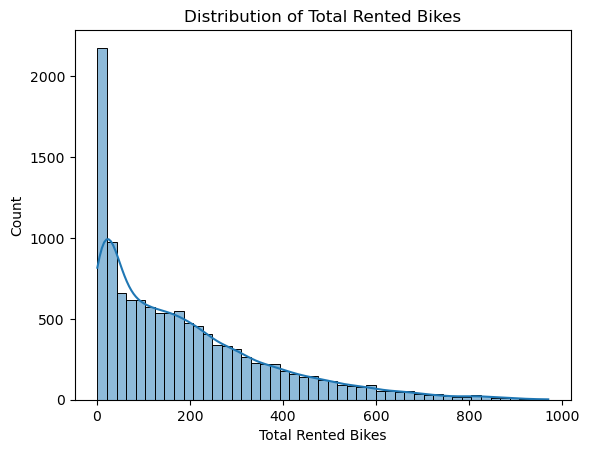

In [54]:
sns.histplot(df['cnt'], kde=True)
plt.title('Distribution of Total Rented Bikes',)
plt.xlabel('Total Rented Bikes')

The Distribution of Total Rented Bikes (`cnt`) is not normally distributed and heavily right-skewed, with  the most frequent amount between 0-20 bikes.

#### **Total Rents by Hour**

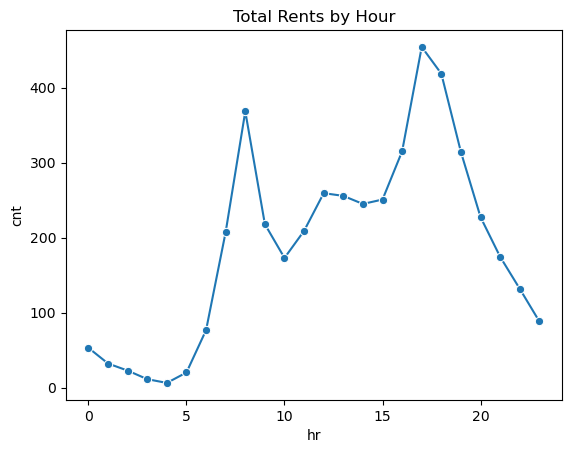

In [55]:
sns.lineplot(data=df, x='hr', y='cnt', marker='o',errorbar=None)
plt.title('Total Rents by Hour', size = 12)
plt.show()

Going by the Hours in a day, we can see that effective rent time is between **05.00** and **23.00** with peaks in rent on **08.00** and **17.00**

#### **Total Rents by Season**

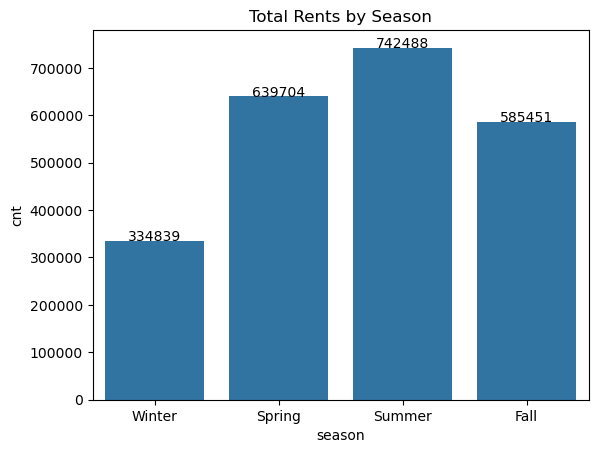

In [56]:
season = ['Winter', 'Spring', 'Summer', 'Fall']
sns.barplot(
    data = df.groupby(by='season')[['cnt']].sum(),
    x = 'season',
    y = 'cnt',
    
)
plt.title('Total Rents by Season')
plt.xticks(ticks=[0, 1, 2, 3], labels=season)
for index, row in df.groupby(by='season')[['cnt']].sum().reset_index().iterrows():
    plt.text(index, row.cnt, round(row.cnt, 2), color='black', ha="center")
plt.show()

Rents in the Summer are higher than the other seasons. Bike rents in the Winter are noticably lower than the other seasons

#### **Total Rents by Temperature**

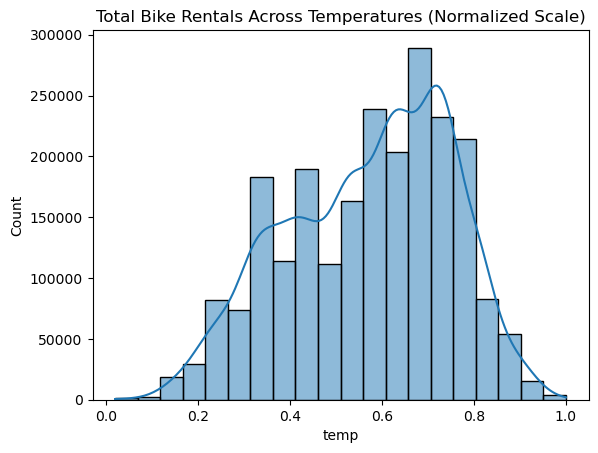

In [57]:
sns.histplot(data=df, x='temp', weights='cnt', bins=20, kde=True)
plt.title("Total Bike Rentals Across Temperatures (Normalized Scale)")
plt.show()

Most bike rents occur when the temperature is at **0.6 - 0.8** on a normalized scale

#### **Total Rents by Humidity**

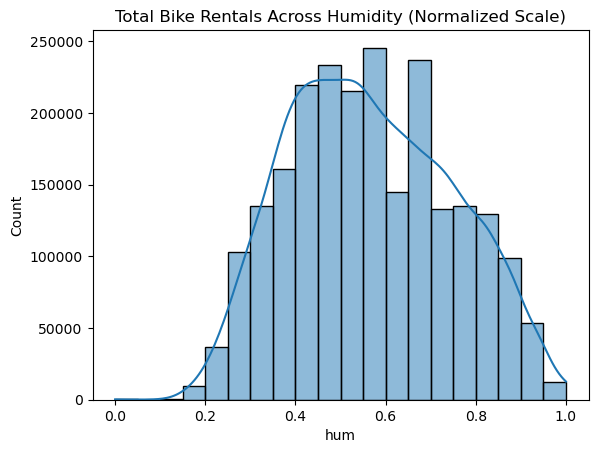

In [58]:
sns.histplot(data=df, x='hum', weights='cnt', bins=20, kde=True)
plt.title("Total Bike Rentals Across Humidity (Normalized Scale)")
plt.show()

Most bike rents occur when the humidity is at **0.4 - 0.7** on a normalized scale

#### **Total Rents by Weather Conditions**

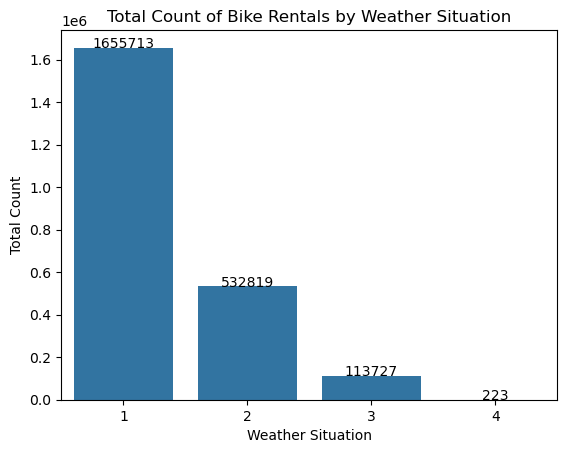

In [59]:
# Draw a bar chart of total count based on weathersit
sns.barplot(
    data=df.groupby(by='weathersit')[['cnt']].sum().reset_index(),
    x='weathersit',
    y='cnt'
)
plt.title('Total Count of Bike Rentals by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Total Count')
for index, row in df.groupby(by='weathersit')[['cnt']].sum().reset_index().iterrows():
    plt.text(row.name, row.cnt, round(row.cnt, 2), color='black', ha="center")
plt.show()

weathersit:
-	1: Clear, Few clouds, Partly cloudy, Partly cloudy
-	2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
-	3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
-	4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

Most bike rentals happen in Clear weather, while virtually almost no rents occurs at Heavy weathers


#### **Total Rents by Holiday**

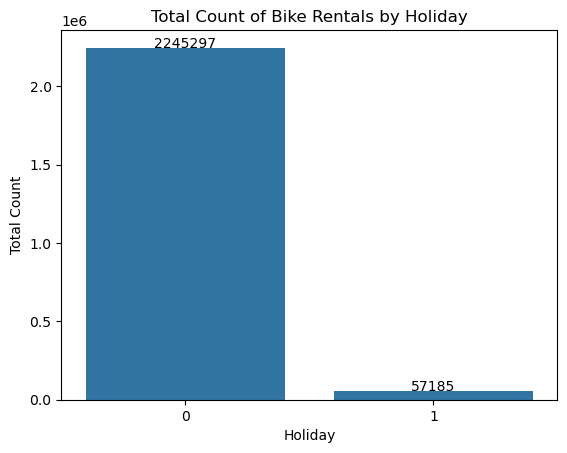

In [60]:
sns.barplot(
    data=df.groupby(by='holiday')[['cnt']].sum().reset_index(),
    x='holiday',
    y='cnt'
)
plt.title('Total Count of Bike Rentals by Holiday')
plt.xlabel('Holiday')
plt.ylabel('Total Count')
for index, row in df.groupby(by='holiday')[['cnt']].sum().reset_index().iterrows():
    plt.text(row.name, row.cnt, round(row.cnt, 2), color='black', ha="center")
plt.show()

Almost all bike rents occur during non-holiday

****
## **3. Data Preprocessing**

### **Check and Convert Data Type**

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      12165 non-null  object 
 1   hum         12165 non-null  float64
 2   weathersit  12165 non-null  int64  
 3   holiday     12165 non-null  int64  
 4   season      12165 non-null  int64  
 5   atemp       12165 non-null  float64
 6   temp        12165 non-null  float64
 7   hr          12165 non-null  int64  
 8   casual      12165 non-null  int64  
 9   registered  12165 non-null  int64  
 10  cnt         12165 non-null  int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 1.0+ MB


`dteday` indicates date and therefore should be converted to datetime format. Furthermore, we can breakdown the `dteday` column into year, month, and day to add features

In [62]:
# Convert dteday to datetime format
df['dteday'] = pd.to_datetime(df['dteday'])

# Breakdown dteday to year, month and day
df['year'] = df['dteday'].dt.year
df['month'] = df['dteday'].dt.month_name()
df['day'] = df['dteday'].dt.day_name()

# drop dteday as it's no longer used
df.drop(columns=['dteday'],inplace=True)
df

,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt,year,month,day
0,0.62,1,0,4,0.3485,0.36,16,24,226,250,2011,December,Friday
1,0.64,1,0,2,0.5152,0.54,4,2,16,18,2012,June,Sunday
2,0.53,1,0,2,0.6212,0.62,23,17,90,107,2011,June,Wednesday
3,0.87,2,0,2,0.3485,0.36,8,19,126,145,2012,March,Saturday
4,0.55,1,0,3,0.6970,0.76,18,99,758,857,2012,July,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12160,0.75,1,0,1,0.2273,0.24,7,14,243,257,2012,January,Wednesday
12161,0.62,1,0,3,0.7424,0.78,0,39,63,102,2012,July,Friday
12162,0.60,2,1,1,0.2121,0.24,5,0,6,6,2012,February,Monday
12163,0.77,2,0,2,0.4242,0.42,2,14,55,69,2012,March,Saturday


The `season` column indicates the season with:
- 1 as Winter
- 2 as Spring
- 3 as Summer
- 4 as Fall

therefore it's better to map the numbers to the corresponding seasons to avoid treating the `season` column as integer or float where in fact it is categorical


In [63]:
# map the season column to the corresponding season
df['season'] = df['season'].map({1: 'winter', 2: 'spring', 3: 'summer', 4: 'fall'})
df

,hum,weathersit,holiday,season,atemp,temp,hr,casual,registered,cnt,year,month,day
0,0.62,1,0,fall,0.3485,0.36,16,24,226,250,2011,December,Friday
1,0.64,1,0,spring,0.5152,0.54,4,2,16,18,2012,June,Sunday
2,0.53,1,0,spring,0.6212,0.62,23,17,90,107,2011,June,Wednesday
3,0.87,2,0,spring,0.3485,0.36,8,19,126,145,2012,March,Saturday
4,0.55,1,0,summer,0.6970,0.76,18,99,758,857,2012,July,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12160,0.75,1,0,winter,0.2273,0.24,7,14,243,257,2012,January,Wednesday
12161,0.62,1,0,summer,0.7424,0.78,0,39,63,102,2012,July,Friday
12162,0.60,2,1,winter,0.2121,0.24,5,0,6,6,2012,February,Monday
12163,0.77,2,0,spring,0.4242,0.42,2,14,55,69,2012,March,Saturday


To further avoid confusion between numerical and categorical features, convert the columns that are categorical to the category data type

In [64]:
# Convert data to categorical
df['weathersit'] = df['weathersit'].astype('category')
df['holiday'] = df['holiday'].astype('category')
df['season'] = df['season'].astype('category')
df['year'] = df['year'].astype('category')
df['month'] = df['month'].astype('category')
df['day'] = df['day'].astype('category')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12165 entries, 0 to 12164
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   hum         12165 non-null  float64 
 1   weathersit  12165 non-null  category
 2   holiday     12165 non-null  category
 3   season      12165 non-null  category
 4   atemp       12165 non-null  float64 
 5   temp        12165 non-null  float64 
 6   hr          12165 non-null  int64   
 7   casual      12165 non-null  int64   
 8   registered  12165 non-null  int64   
 9   cnt         12165 non-null  int64   
 10  year        12165 non-null  category
 11  month       12165 non-null  category
 12  day         12165 non-null  category
dtypes: category(6), float64(3), int64(4)
memory usage: 738.0 KB


**Additional EDA for new Features**

C:\Users\Asus\AppData\Local\Temp\ipykernel_61920\4253335042.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby(by=i)[['cnt']].sum().reset_index(),


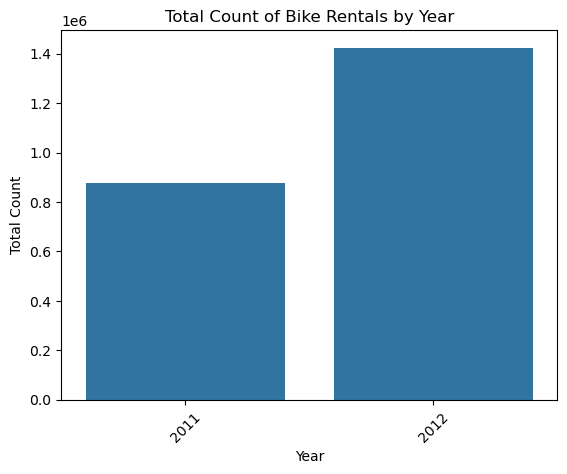

C:\Users\Asus\AppData\Local\Temp\ipykernel_61920\4253335042.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby(by=i)[['cnt']].sum().reset_index(),


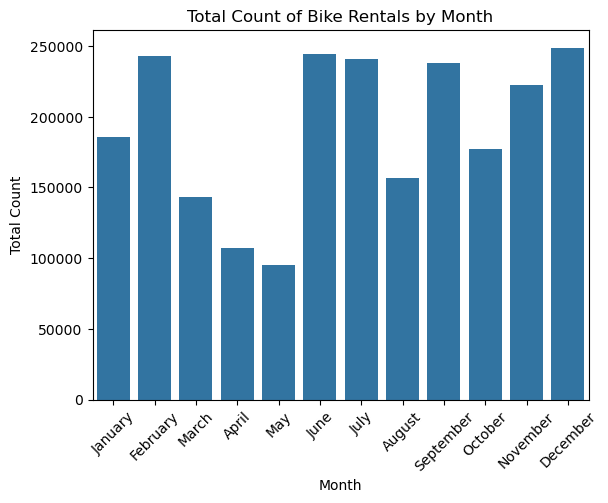

C:\Users\Asus\AppData\Local\Temp\ipykernel_61920\4253335042.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=df.groupby(by=i)[['cnt']].sum().reset_index(),


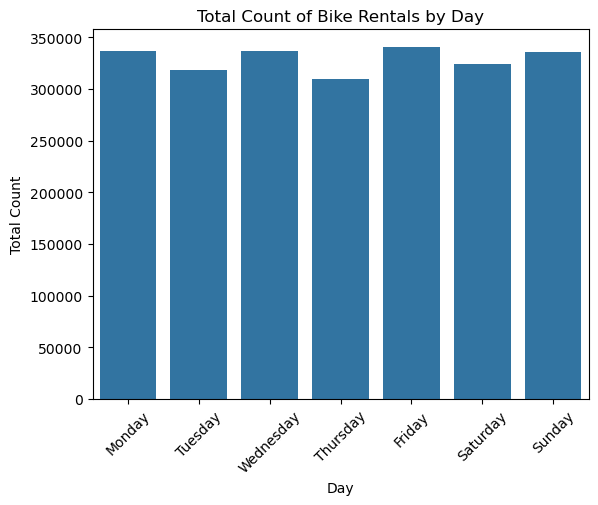

In [135]:
for i in ['year','month','day']:
    sns.barplot(
        data=df.groupby(by=i)[['cnt']].sum().reset_index(),
        x=i,
        y='cnt'
    )
    plt.title(f'Total Count of Bike Rentals by {i.capitalize()}')
    plt.xlabel(i.capitalize())
    plt.ylabel('Total Count')
    plt.xticks(rotation=45)
    if i == 'month':
        plt.xticks(ticks=range(12), labels=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=45)
    elif i == 'day':
        plt.xticks(ticks=range(7), labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], rotation=45)
    plt.show()


- Bike rents in the first half of the year are lower compared to the later half
- Rents by weekdays are distributed almost evenly

### **Drop Irrelevant Features**

Irrelevant Features:
- `registered` : Count of Registered Customer
- `casual`: Count of Casual Customer

The target of this dataset `cnt` is the sum of `registered` and `casual`, therefore they are not suitable to be used as a feature

In [66]:
df_model = df.copy()
df_model.drop(columns=['registered','casual'],inplace=True)
df_model

,hum,weathersit,holiday,season,atemp,temp,hr,cnt,year,month,day
0,0.62,1,0,fall,0.3485,0.36,16,250,2011,December,Friday
1,0.64,1,0,spring,0.5152,0.54,4,18,2012,June,Sunday
2,0.53,1,0,spring,0.6212,0.62,23,107,2011,June,Wednesday
3,0.87,2,0,spring,0.3485,0.36,8,145,2012,March,Saturday
4,0.55,1,0,summer,0.6970,0.76,18,857,2012,July,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...
12160,0.75,1,0,winter,0.2273,0.24,7,257,2012,January,Wednesday
12161,0.62,1,0,summer,0.7424,0.78,0,102,2012,July,Friday
12162,0.60,2,1,winter,0.2121,0.24,5,6,2012,February,Monday
12163,0.77,2,0,spring,0.4242,0.42,2,69,2012,March,Saturday


In [ ]:
sns.

Another Irrelevant Feature would be either `atemp` or `temp`, as they both represent temperature, with temp being the recorded actual temperature with a local thermometer and atemp being the feeling temperature

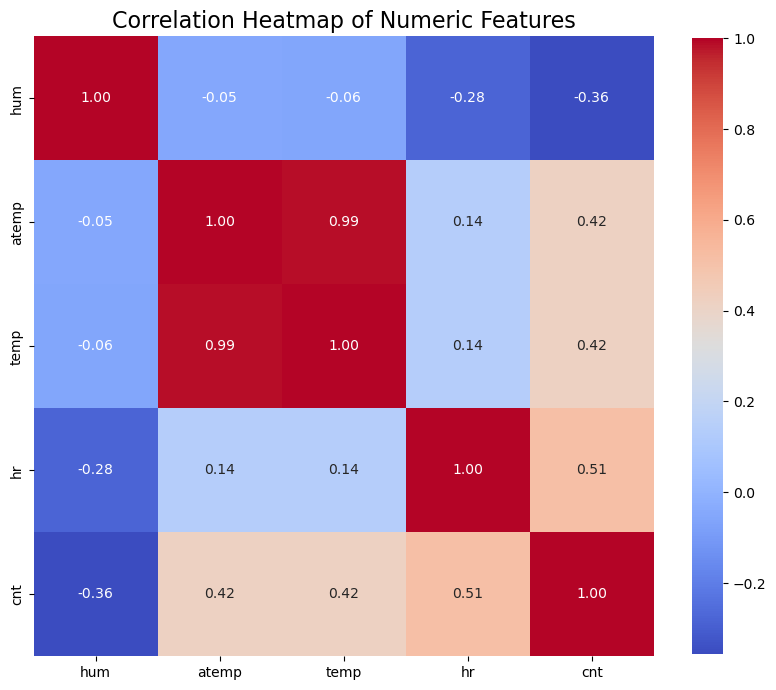

In [67]:
# Define the numeric features to visualize
numeric_features = df_model.select_dtypes(include='number')

# Set up the matplotlib figure with a 2x2 grid
plt.figure(figsize=(10, 10))

# Calculate the correlation matrix
correlation_matrix = numeric_features.corr(method='spearman')

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

# Set title
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)

# Show the plot
plt.show()


As we can see `temp` and `atemp` have a 0.99 correlation and indicates multicollinearity. Therefore, we should drop one of them. In this case, we will drop `atemp`.

In [68]:
# drop atemp as it's highly correlated with temp
df_model.drop(columns='atemp',inplace=True)

The `year` column indicates the year the data was recorded. The dataset only provides data from 2011 and 2012 and might limit the model so it can't predict outside of 2011 and 2012. Therefore it's better to drop the `year` column

In [69]:
# drop year as it's not useful for the model
df_model.drop(columns='year',inplace=True)

### **Missing Values**

In [70]:
# Check for Missing Values
df_model.isna().sum()

hum           0
weathersit    0
holiday       0
season        0
temp          0
hr            0
cnt           0
month         0
day           0
dtype: int64

- There are no Missing values found in the Dataset, therefore there is no need for dropping or imputing columns and rows with missing datas

### **Duplicated Values**

In [71]:
# Sum of Duplicated Rows
df_model.duplicated().sum()

1

In [72]:
# Drop Duplicate Rows
df_model.drop_duplicates(inplace=True)

### **Check for Outliers**

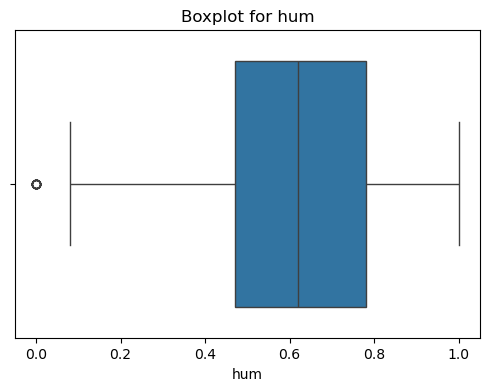

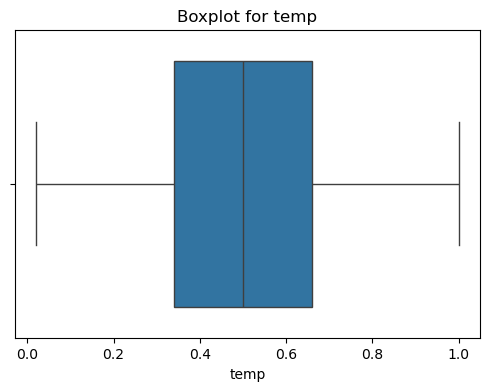

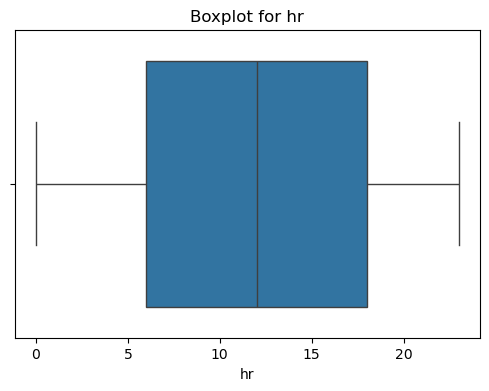

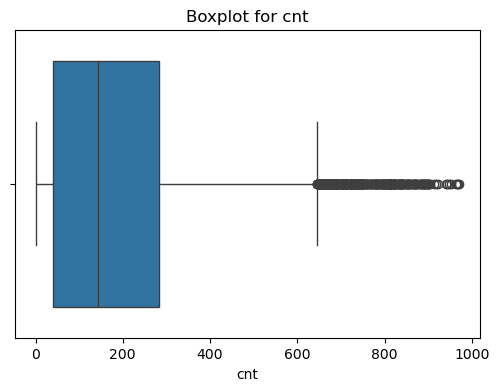

In [73]:
# Select numerical columns
numerical_columns = df_model.select_dtypes(include=['float64', 'int64']).columns

# Create boxplot
for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_model[column])
    plt.title(f'Boxplot for {column}')
    plt.show()

All numerical features have little to no outliers and remain within an acceptable range, except for the `cnt` column. However, since `cnt` is the target variable for this model, it is best not to remove its outliers. Doing so could limit the model’s ability to learn from extreme values, which may be important for accurate predictions

****
## **4. Modeling**

In [74]:
# Import library for modeling

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV, KFold

import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PolynomialFeatures

from category_encoders import BinaryEncoder, OrdinalEncoder

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

### **Define Feature and Target**

Since the target variable (bike count) has a heavily right-skewed distribution, applying a log transformation makes the data more normally distributed. This helps the model in two key ways:

- Stabilizes Variance: Reduces the impact of extreme values, making predictions more balanced.
- Improves Accuracy: Many regression models perform better when the target follows a normal-like distribution.

By training the model on the log-transformed target, we make predictions in log scale and then exponentiate them to convert back to actual bike counts. This ensures more stable and accurate predictions.

In [75]:
X = df_model.drop(columns=['cnt'])
y = np.log1p(df_model['cnt'])

### **Train and Test Splitting**

80% Train Data, 20% Test Data

In [76]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,  
    test_size=0.2,
    random_state=0)

### **Encoding & Scaling**

- Encoding:
    - OneHot : `weathersit`, `holiday`, `season`
    - BinaryEncoder : `month`, `day`

- Scaling:
    - RobustScaler: `hr`

- Polynomial Features: 
    - `temp`, `hum`, `hr`

In [77]:
pipe_for_hour = Pipeline([
    ('RobustScaler', RobustScaler()),
    ('PolynomialFeatures', PolynomialFeatures(degree=2))
    
])
transformer = ColumnTransformer([
    ('One Hot', OneHotEncoder(drop='first'), ['weathersit', 'holiday','season']),
    ('Binary', BinaryEncoder(), ['month','day']),
    ('Hour', pipe_for_hour, ['hr']),
    ('Poly', PolynomialFeatures(degree=2), ['temp','hum'])
    
], remainder='passthrough')

### **Benchmark Model**

- This process is intended to compare various models based on the Metric evaluations using a benchmark parameter

- Models are trained with the log-transformed target which then would be exponentiated back to give us the actual value

####  **Actual Values (y not log-transformed)**

In [78]:
# Define Algorithms
lr = LinearRegression()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor(random_state=0)
rf = RandomForestRegressor(random_state=0)
xgb = XGBRegressor(random_state=0)

# Scaling
scaler = RobustScaler()

# Algorithm Candidates
models = [lr, knn, dt, rf, xgb]

nilai_mean_rmse = []
nilai_std_rmse = []

nilai_mean_mae = []
nilai_std_mae = []

nilai_mean_mape = []
nilai_std_mape = []

r2_mean = []
r2_std = []

# Finding best Algorithm by metrics
for i in models:
    
    crossval = KFold(n_splits=5, shuffle=True, random_state=0)

    estimator = Pipeline([
        ('preprocessing', transformer),
        ('model', i)
    ])

    # RMSE
    model_cv_rmse = cross_val_score(
        estimator, 
        X_train, 
        np.expm1(y_train), 
        cv=crossval, 
        scoring='neg_root_mean_squared_error', 
        error_score='raise'
        )

    nilai_mean_rmse.append(model_cv_rmse.mean())
    nilai_std_rmse.append(model_cv_rmse.std())

    # MAE
    model_cv_mae = cross_val_score(
        estimator, 
        X_train, 
        np.expm1(y_train), 
        cv=crossval, 
        scoring='neg_mean_absolute_error', 
        error_score='raise'
        )

    nilai_mean_mae.append(model_cv_mae.mean())
    nilai_std_mae.append(model_cv_mae.std())

    # MAPE
    model_cv_mape = cross_val_score(
        estimator, 
        X_train, 
        np.expm1(y_train), 
        cv=crossval, 
        scoring='neg_mean_absolute_percentage_error', 
        error_score='raise'
        )

    nilai_mean_mape.append(model_cv_mape.mean())
    nilai_std_mape.append(model_cv_mape.std())

    # R2
    model_cv_r2 = cross_val_score(
        estimator, 
        X_train, 
        np.expm1(y_train), 
        cv=crossval, 
        scoring='r2', 
        error_score='raise'
        )

    r2_mean.append(model_cv_r2.mean())
    r2_std.append(model_cv_r2.std())

In [79]:
# Evaluation of Algorithms Used
algo_eval_actual = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regressor', 'DecisionTree Regressor', 'RandomForest Regressor', 'XGBoost Regressor'],
    'Mean_RMSE': nilai_mean_rmse,
    'Std_RMSE': nilai_std_rmse,
    'Mean_MAE': nilai_mean_mae,
    'Std_MAE': nilai_std_mae,
    'Mean_MAPE': nilai_mean_mape,
    'Std_MAPE': nilai_std_mape,
    'Mean_R2': r2_mean,
    'Std_R2': r2_std
})
algo_eval_actual

,Model,Mean_RMSE,Std_RMSE,Mean_MAE,Std_MAE,Mean_MAPE,Std_MAPE,Mean_R2,Std_R2
0,Linear Regression,-134.355637,4.474499,-99.721361,1.529297,-2.963022,0.196378,0.449477,0.011442
1,KNN Regressor,-113.270715,3.793560,-75.727133,1.520097,-1.679515,0.155290,0.608735,0.007082
2,DecisionTree Regressor,-102.530059,6.792253,-63.912055,4.306465,-0.591674,0.091445,0.674601,0.066792
3,RandomForest Regressor,-74.140052,3.714809,-48.952697,2.855495,-0.525499,0.071424,0.830420,0.029010
4,XGBoost Regressor,-72.302922,4.448913,-48.371029,3.202522,-0.662843,0.052561,0.838372,0.031614


- **For Actual Values (y not log-transformed)**:
    - Based on RMSE, XGBoost Regressor is the best model

    - XGBoost Regressor also comes as the best in MAE, although it is very similar to RandomForest

    - RandomForest Regressor comes as the best in MAPE, although it is more unstable (std is higher)

    - RandomForest Regressor and XGBoost Regressor has good R-squared Values

for actual values, both XGBoost and Random Forest performs almost similarly well

#### **Log-Transformed y**

In [80]:
# Define Algorithms
lr = LinearRegression()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor(random_state=0)
rf = RandomForestRegressor(random_state=0)
xgb = XGBRegressor(random_state=0)

# Scaling
scaler = RobustScaler()

# Algorithm Candidates
models = [lr, knn, dt, rf, xgb]

nilai_mean_rmse = []
nilai_std_rmse = []

nilai_mean_mae = []
nilai_std_mae = []

nilai_mean_mape = []
nilai_std_mape = []

r2_mean = []
r2_std = []

# Finding best Algorithm by metrics
for i in models:
    
    crossval = KFold(n_splits=5, shuffle=True, random_state=0)

    estimator = Pipeline([
        ('preprocessing', transformer),
        ('model', i)
    ])

    # RMSE
    model_cv_rmse = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='neg_root_mean_squared_error', 
        error_score='raise'
        )

    nilai_mean_rmse.append(model_cv_rmse.mean())
    nilai_std_rmse.append(model_cv_rmse.std())

    # MAE
    model_cv_mae = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='neg_mean_absolute_error', 
        error_score='raise'
        )

    nilai_mean_mae.append(model_cv_mae.mean())
    nilai_std_mae.append(model_cv_mae.std())

    # MAPE
    model_cv_mape = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='neg_mean_absolute_percentage_error', 
        error_score='raise'
        )

    nilai_mean_mape.append(model_cv_mape.mean())
    nilai_std_mape.append(model_cv_mape.std())

    # R2
    model_cv_r2 = cross_val_score(
        estimator, 
        X_train, 
        y_train, 
        cv=crossval, 
        scoring='r2', 
        error_score='raise'
        )

    r2_mean.append(model_cv_r2.mean())
    r2_std.append(model_cv_r2.std())

In [81]:
# Evaluation of Algorithms Used
algo_eval_logtransformed = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regressor', 'DecisionTree Regressor', 'RandomForest Regressor', 'XGBoost Regressor'],
    'Mean_RMSE': nilai_mean_rmse,
    'Std_RMSE': nilai_std_rmse,
    'Mean_MAE': nilai_mean_mae,
    'Std_MAE': nilai_std_mae,
    'Mean_MAPE': nilai_mean_mape,
    'Std_MAPE': nilai_std_mape,
    'Mean_R2': r2_mean,
    'Std_R2': r2_std
})
algo_eval_logtransformed

,Model,Mean_RMSE,Std_RMSE,Mean_MAE,Std_MAE,Mean_MAPE,Std_MAPE,Mean_R2,Std_R2
0,Linear Regression,-0.898765,0.013259,-0.678525,0.011072,-0.227354,0.011290,0.595571,0.017648
1,KNN Regressor,-0.732240,0.010705,-0.528093,0.006971,-0.174025,0.009083,0.731523,0.012411
2,DecisionTree Regressor,-0.613392,0.069866,-0.444134,0.044588,-0.130486,0.013011,0.806301,0.061752
3,RandomForest Regressor,-0.444801,0.048634,-0.331282,0.032844,-0.100578,0.008812,0.898300,0.031359
4,XGBoost Regressor,-0.401029,0.020211,-0.301306,0.012752,-0.091315,0.003289,0.918723,0.013789


- For Log-Transformed y values:
    - XGBoost is the best in every metrics

### **Predict with the Benchmark Model**

#### **Model Fitted with Actual Values (y not log-transformed)**

Predict to Test Set

In [82]:
# Benchmark 2 model terbaik
models = {
    'XGB': XGBRegressor(random_state=0),
    'RandomForest': RandomForestRegressor(random_state=0)
}

score_rmse = []
score_mae = []
score_mape = []
score_r2 = []

# Prediksi pada test set
for i in models:

    model = Pipeline([
        ('preprocessing', transformer),
        ('scaler', scaler),
        ('model', models[i])
        ])

    # model.fit(X_train, y_train)
    # y_pred = np.expm1(model.predict(X_test))
    # score_rmse.append(np.sqrt(mean_squared_error(np.expm1(y_test), y_pred)))
    # score_mae.append(mean_absolute_error(np.expm1(y_test), y_pred))
    # score_mape.append(mean_absolute_percentage_error(np.expm1(y_test), y_pred))
    # score_r2.append(r2_score(np.expm1(y_test), y_pred))

    # MODEL FITTED USING ACTUAL TARGET
    model.fit(X_train, np.expm1(y_train))

    # Prediction
    y_pred = model.predict(X_test)

    
    score_rmse.append(np.sqrt(mean_squared_error(np.expm1(y_test), y_pred)))
    score_mae.append(mean_absolute_error(np.expm1(y_test), y_pred))
    score_mape.append(mean_absolute_percentage_error(np.expm1(y_test), y_pred))
    score_r2.append(r2_score(np.expm1(y_test), y_pred))


In [83]:
score_before_tuning_test = pd.DataFrame({'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape,'R2':score_r2}, index=models.keys())
score_before_tuning_test

,RMSE,MAE,MAPE,R2
XGB,67.706227,45.38454,0.627641,0.860405
RandomForest,73.307465,48.04392,0.458265,0.836353


Predict to Train Set

In [84]:
# Benchmark 2 model terbaik
models = {
    'XGB': XGBRegressor(random_state=0),
    'RandomForest': RandomForestRegressor(random_state=0)
}

score_rmse = []
score_mae = []
score_mape = []
score_r2 = []

# Prediksi pada test set
for i in models:

    model = Pipeline([
        ('preprocessing', transformer),
        ('scaler', scaler),
        ('model', models[i])
        ])

    # MODEL FITTED USING ACTUAL TARGET
    model.fit(X_train, np.expm1(y_train))
    
    # Prediction
    y_pred = model.predict(X_train)
    
    score_rmse.append(np.sqrt(mean_squared_error(np.expm1(y_train), y_pred)))
    score_mae.append(mean_absolute_error(np.expm1(y_train), y_pred))
    score_mape.append(mean_absolute_percentage_error(np.expm1(y_train), y_pred))
    score_r2.append(r2_score(np.expm1(y_train), y_pred))

In [85]:
score_before_tuning_train = pd.DataFrame({'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape,'R2':score_r2}, index=models.keys())
score_before_tuning_train

,RMSE,MAE,MAPE,R2
XGB,45.317095,30.276831,0.457505,0.937464
RandomForest,26.846194,17.372765,0.170143,0.978053


In [86]:
result_actual_y = pd.concat([score_before_tuning_train, score_before_tuning_test], axis=1)
result_actual_y.columns = ['RMSE Train', 'MAE Train', 'MAPE Train', 'R2 Train', 'RMSE Test', 'MAE Test', 'MAPE Test', 'R2 Test']
result_actual_y

,RMSE Train,MAE Train,MAPE Train,R2 Train,RMSE Test,MAE Test,MAPE Test,R2 Test
XGB,45.317095,30.276831,0.457505,0.937464,67.706227,45.38454,0.627641,0.860405
RandomForest,26.846194,17.372765,0.170143,0.978053,73.307465,48.04392,0.458265,0.836353


#### **Model Fitted with Log-Transformed y**

Predict to Train Set

In [87]:
# Benchmark 2 model terbaik
models = {
    'XGB': XGBRegressor(random_state=0),
    'RandomForest': RandomForestRegressor(random_state=0)
}

score_rmse = []
score_mae = []
score_mape = []
score_r2 = []

# Prediksi pada test set
for i in models:

    model = Pipeline([
        ('preprocessing', transformer),
        ('scaler', scaler),
        ('model', models[i])
        ])

    # MODEL FITTED USING LOG TRANSFORMED TARGET
    model.fit(X_train, y_train)

    # Prediction (Convert back to original scale)
    y_pred = np.expm1(model.predict(X_train))

    score_rmse.append(np.sqrt(mean_squared_error(np.expm1(y_train), y_pred)))
    score_mae.append(mean_absolute_error(np.expm1(y_train), y_pred))
    score_mape.append(mean_absolute_percentage_error(np.expm1(y_train), y_pred))
    score_r2.append(r2_score(np.expm1(y_train), y_pred))

In [88]:
score_before_tuning_train = pd.DataFrame({'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape,'R2':score_r2}, index=models.keys())
score_before_tuning_train

,RMSE,MAE,MAPE,R2
XGB,51.816704,31.632762,0.214430,0.918239
RandomForest,29.772736,17.830313,0.126341,0.973007


Predict to Test Set

In [89]:
# Benchmark 2 model terbaik
models = {
    'XGB': XGBRegressor(random_state=0),
    'RandomForest': RandomForestRegressor(random_state=0)
}

score_rmse = []
score_mae = []
score_mape = []
score_r2 = []

# Prediksi pada test set
for i in models:

    model = Pipeline([
        ('preprocessing', transformer),
        ('scaler', scaler),
        ('model', models[i])
        ])

    # MODEL FITTED USING LOG TRANSFORMED TARGET
    model.fit(X_train, y_train)

    # Prediction (Convert back to original scale)
    y_pred = np.expm1(model.predict(X_test))

    score_rmse.append(np.sqrt(mean_squared_error(np.expm1(y_test), y_pred)))
    score_mae.append(mean_absolute_error(np.expm1(y_test), y_pred))
    score_mape.append(mean_absolute_percentage_error(np.expm1(y_test), y_pred))
    score_r2.append(r2_score(np.expm1(y_test), y_pred))

In [90]:
score_before_tuning_test = pd.DataFrame({'RMSE': score_rmse, 'MAE': score_mae, 'MAPE': score_mape,'R2':score_r2}, index=models.keys())
score_before_tuning_test

,RMSE,MAE,MAPE,R2
XGB,66.014560,42.726360,0.349848,0.867294
RandomForest,73.812831,47.284703,0.387871,0.834089


In [91]:
result_logtransformed_y = pd.concat([score_before_tuning_train, score_before_tuning_test], axis=1)
result_logtransformed_y.columns = ['RMSE Train', 'MAE Train', 'MAPE Train', 'R2 Train', 'RMSE Test', 'MAE Test', 'MAPE Test', 'R2 Test']
result_logtransformed_y

,RMSE Train,MAE Train,MAPE Train,R2 Train,RMSE Test,MAE Test,MAPE Test,R2 Test
XGB,51.816704,31.632762,0.214430,0.918239,66.014560,42.726360,0.349848,0.867294
RandomForest,29.772736,17.830313,0.126341,0.973007,73.812831,47.284703,0.387871,0.834089


#### **Comparison Between Actual y and Log-Transformed y**

In [92]:
display(result_actual_y, result_logtransformed_y)

,RMSE Train,MAE Train,MAPE Train,R2 Train,RMSE Test,MAE Test,MAPE Test,R2 Test
XGB,45.317095,30.276831,0.457505,0.937464,67.706227,45.38454,0.627641,0.860405
RandomForest,26.846194,17.372765,0.170143,0.978053,73.307465,48.04392,0.458265,0.836353


,RMSE Train,MAE Train,MAPE Train,R2 Train,RMSE Test,MAE Test,MAPE Test,R2 Test
XGB,51.816704,31.632762,0.214430,0.918239,66.014560,42.726360,0.349848,0.867294
RandomForest,29.772736,17.830313,0.126341,0.973007,73.812831,47.284703,0.387871,0.834089


- Both the Actual y and Log-Transformed y shows signs of overfitting which can be tackled with hyperparameter tuning.

- Based on RMSE and MAE, both the Actual y and Log-Transformed y performs similarly

- However based on MAPE, the Log-Transformed y performs much better

- This validates the assumption on why we Log-Transform the target to reduce errors

- XGB appears to be the more stable between the two model and will be used

### **Hyperparameter Tuning**

#### **Hyperparameters**

In [93]:
hyperparam_space_xgb = {
    'model__max_depth': np.arange(3, 11).tolist(), # Moderate depth (avoid too deep or shallow)
    'model__learning_rate': np.linspace(0.001, 0.08, 20).tolist(),  # Small steps to prevent instability
    'model__n_estimators': np.linspace(100, 800, 20, dtype=int).tolist(),  # More trees for better learning
    'model__subsample': np.linspace(0.6, 0.9, 10).tolist(),  # Reduce reliance on one subset of data
    'model__colsample_bytree': np.linspace(0.6, 0.9, 10).tolist(),  # Use a subset of features for better generalization
    'preprocessing__Poly__degree': [1, 2, 3],  # Polynomial features,
    'preprocessing__Hour__PolynomialFeatures__degree': [1, 2, 3],  # Polynomial features for hr,
    'model__reg_alpha': np.logspace(-2, 1, 5).tolist(),  # 5 values (stronger regularization)
    'model__reg_lambda': np.logspace(-2, 1, 5).tolist(),  # 5 values (stronger regularization)

}

#### **Tuning**

In [94]:
# Benchmark model dengan hyperparameter tuning
# xgb = XGBRegressor(random_state=1, verbosity=0)
xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",  # Gunakan metode lebih cepat
     
)
# Membuat algorithm chains
estimator_xgb = Pipeline([
        ('preprocessing', transformer),
        ('scaler', scaler),
        ('model', xgb)
        ])

crossval = KFold(n_splits=5, shuffle=True, random_state=1)

# Hyperparameter tuning
random_xgb = RandomizedSearchCV(
    estimator_xgb, 
    param_distributions = hyperparam_space_xgb,
    n_iter = 200,
    cv = crossval, 
    scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'], 
    n_jobs = -1,
    verbose=2,
    refit = 'neg_mean_absolute_percentage_error', # Best model based on single metric
    random_state = 0 
)

In [95]:
# Fitting training data (Log-Transformed)
random_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('One '
                                                                               'Hot',
                                                                               OneHotEncoder(drop='first'),
                                                                               ['weathersit',
                                                                                'holiday',
                                                                                'season']),
                                                                              ('Binary',
                                                                               BinaryEncoder(),
                                                                               ['month',
                                                                                'day']),
                                                                              ('Hour',
                                                                               Pipeline(steps=[('RobustScaler',
                                                                                                RobustScaler()),
                                                                                               ('Polynom...
                                                             0.7333333333333334,
                                                             0.7666666666666666,
                                                             0.8,
                                                             0.8333333333333334,
                                                             0.8666666666666667,
                                                             0.9],
                                        'preprocessing__Hour__PolynomialFeatures__degree': [1,
                                                                                            2,
                                                                                            3],
                                        'preprocessing__Poly__degree': [1, 2,
                                                                        3]},
                   random_state=0, refit='neg_mean_absolute_percentage_error',
                   scoring=['neg_root_mean_squared_error',
                            'neg_mean_absolute_error',
                            'neg_mean_absolute_percentage_error'],
                   verbose=2)

In [96]:
random_xgb.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('One Hot',
                                                  OneHotEncoder(drop='first'),
                                                  ['weathersit', 'holiday',
                                                   'season']),
                                                 ('Binary', BinaryEncoder(),
                                                  ['month', 'day']),
                                                 ('Hour',
                                                  Pipeline(steps=[('RobustScaler',
                                                                   RobustScaler()),
                                                                  ('PolynomialFeatures',
                                                                   PolynomialFeatures(degree=1))]),
                                                  ['hr']),
                                                 ('Poly',
                                                  PolynomialFeatures(...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=0.06336842105263157, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=7, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=652, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

Metrics of the best estimator

In [108]:
best_params = random_xgb.best_params_

# Extract the RMSE, MAE, and MAPE
best_rmse = random_xgb.cv_results_['mean_test_neg_root_mean_squared_error'][random_xgb.best_index_]
best_mae = random_xgb.cv_results_['mean_test_neg_mean_absolute_error'][random_xgb.best_index_]
best_mape = random_xgb.cv_results_['mean_test_neg_mean_absolute_percentage_error'][random_xgb.best_index_]

# Convert negative scores to positive
best_rmse = -best_rmse
best_mae = -best_mae
best_mape = -best_mape

# Create a DataFrame with the extracted metrics
best_metrics_df = pd.DataFrame({
    'Model': ['XGB'],
    'Mean_RMSE': [best_rmse],
    'Mean_MAE': [best_mae],
    'Mean_MAPE': [best_mape],
})

best_metrics_df


,Model,Mean_RMSE,Mean_MAE,Mean_MAPE
0,XGB,0.380752,0.288272,0.088219


#### **Predict to Test Set**

- To check if the model is overfitted or underfitted, the MAPE scores of the Test Set (random_xgb.best_score_) and the Train Set will be compared

- The comparison will be done in Log-Transformed values, so no need to exponentiate the prediction results to the actual values just yet

In [109]:
# Define model using best hyperparameter
xgb_tuning = random_xgb.best_estimator_

# Fitting model (using log-transformed target)
xgb_tuning.fit(X_train, y_train)

# Predict test set (not converted back to original scale)
y_pred_xgb_tuning = xgb_tuning.predict(X_test)

# Append Metrics (y_test is still in log-transformed)
rmse_xgb_tuning = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuning))
mae_xgb_tuning = mean_absolute_error(y_test, y_pred_xgb_tuning)
mape_xgb_tuning = mean_absolute_percentage_error(y_test, y_pred_xgb_tuning)
r2_xgb_tuning = r2_score(y_test, y_pred_xgb_tuning)

score_after_tuning_test = pd.DataFrame({'RMSE': rmse_xgb_tuning, 'MAE': mae_xgb_tuning, 'MAPE': mape_xgb_tuning, 'R2':r2_xgb_tuning}, index=['XGB'])
score_after_tuning_test

,RMSE,MAE,MAPE,R2
XGB,0.360333,0.268933,0.085838,0.936235


**Comparison of Train (from RandomizedSearch) and Test (from prediction)**

In [110]:
# Test Train Comparison (Values are in log-transformed)
tuned_train_score = display(best_metrics_df.set_index('Model'),score_after_tuning_test)
tuned_train_score

,Mean_RMSE,Mean_MAE,Mean_MAPE
Model,,,
XGB,0.380752,0.288272,0.088219


,RMSE,MAE,MAPE,R2
XGB,0.360333,0.268933,0.085838,0.936235


Both the Train Set and Test Set show results that are close, indicating that the model is well-fitted with minimal overfitting or underfitting.

Since the model was trained on log-transformed target values, the actual predictions can be obtained by exponentiating the predicted values. Once transformed back to the original scale, we can recalculate the evaluation metrics to assess real-world performance.

In [111]:
# Model XGBoost
model = {'XGB': XGBRegressor(random_state=0)}

# Define model terhadap estimator terbaik
xgb_tuning = random_xgb.best_estimator_

# Fitting model using log-transformed target
xgb_tuning.fit(X_train, y_train)

# Predict test set (converted back to original scale)
y_pred_xgb_tuning = np.expm1(xgb_tuning.predict(X_test))

# Append Metrics (y_test is converted back to original scale)
rmse_xgb_tuning = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_xgb_tuning))
mae_xgb_tuning = mean_absolute_error(np.expm1(y_test), y_pred_xgb_tuning)
mape_xgb_tuning = mean_absolute_percentage_error(np.expm1(y_test), y_pred_xgb_tuning)
r2_xgb_tuning = r2_score(np.expm1(y_test), y_pred_xgb_tuning)

tuned_actual_test_score = pd.DataFrame({'RMSE': rmse_xgb_tuning, 'MAE': mae_xgb_tuning, 'MAPE': mape_xgb_tuning, 'R2':r2_xgb_tuning}, index=model.keys())
tuned_actual_test_score

,RMSE,MAE,MAPE,R2
XGB,63.215661,40.754937,0.337539,0.878308


Based on actual values, this model performs quite well with MAPE of 0.337539

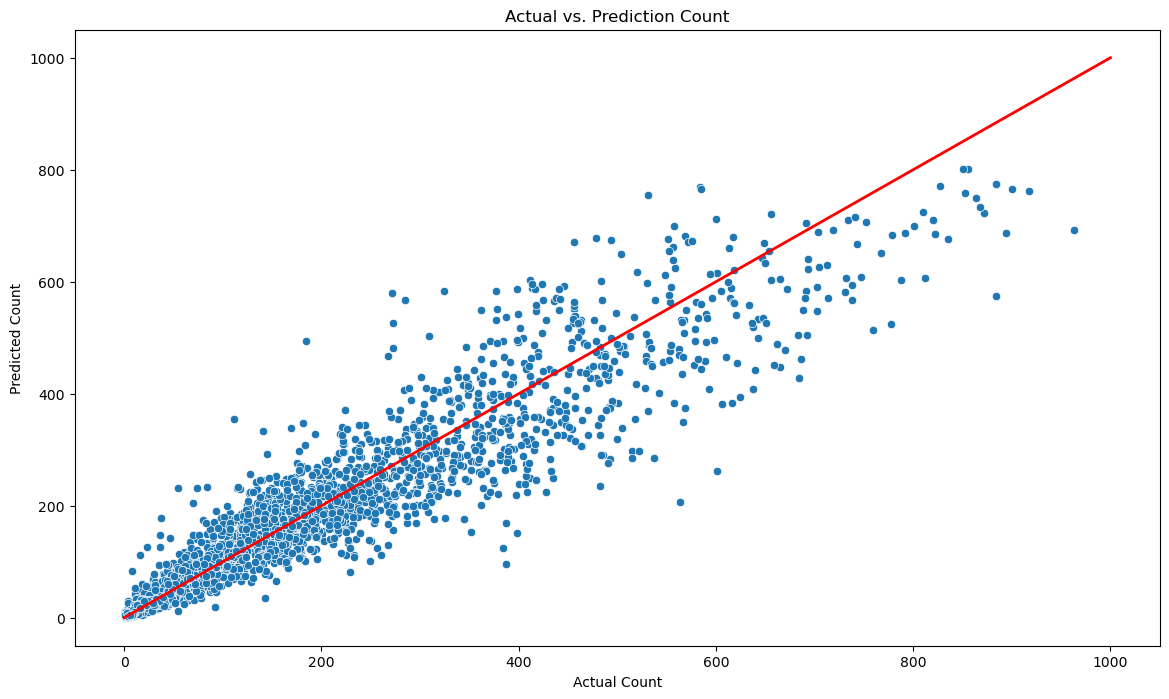

In [112]:
plt.figure(figsize=(14, 8))
plot = sns.scatterplot(x=np.expm1(y_test), y=y_pred_xgb_tuning).set(title='Actual vs. Prediction Count', 
                                               xlabel='Actual Count', 
                                               ylabel='Predicted Count')

plt.plot([0, 1000], [0, 1000], color='red', lw=2)

- Below 400 actual count, predictions appear to be quite accurate.
- For higher actual values (above 400), predictions seem to underestimate the actual counts (points fall below the red line).
- This suggests that the model might struggle to predict during peak demand conditions.

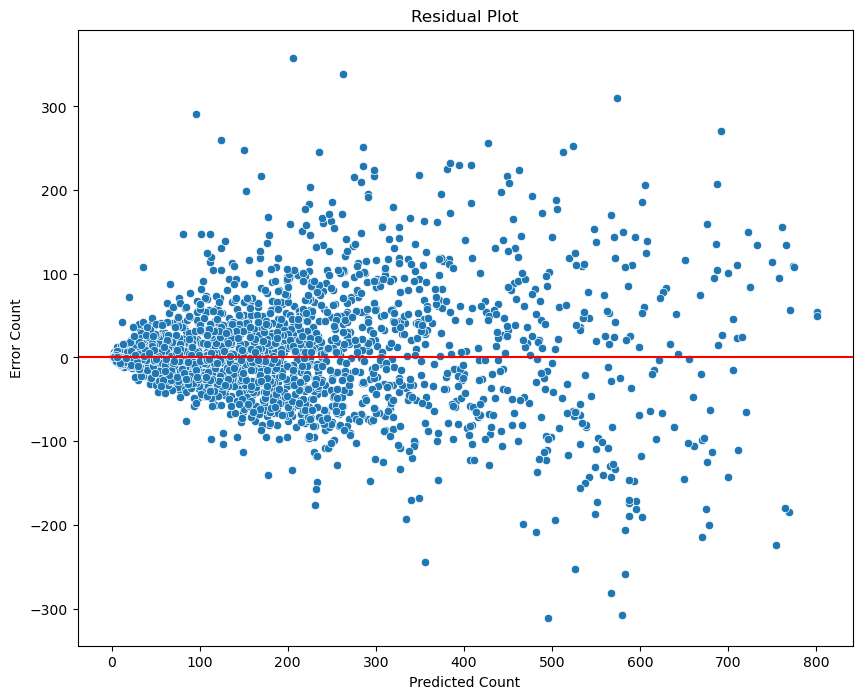

In [113]:
residual = np.expm1(y_test) - y_pred_xgb_tuning

plt.figure(figsize=(10,8))
sns.scatterplot(x=y_pred_xgb_tuning, y=residual).set(title='Residual Plot', xlabel='Predicted Count', ylabel='Error Count')
plt.axhline(y=0, color='r', linestyle='-')
plt.show()

- the model does not seem to have a strong bias (residuals are scattered near the center)
- the model residuals for higher values appear to spread out more, indicating larger errors for higher predictions

### **Feature Importance**

C:\Users\Asus\AppData\Local\Temp\ipykernel_61920\329809105.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='viridis')


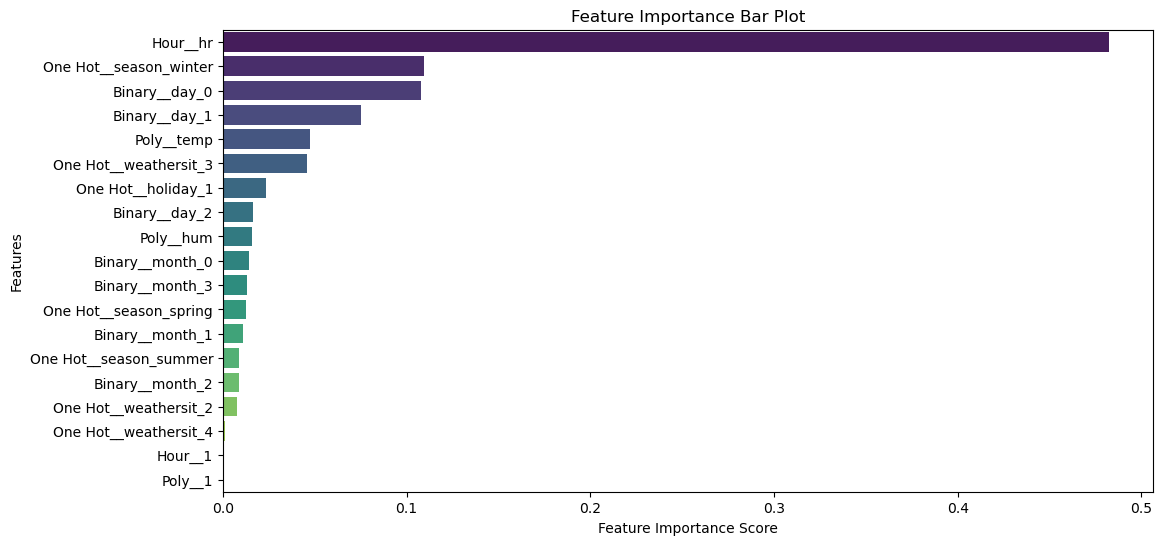

In [114]:
# Extract feature names from the preprocessing step
feature_names = random_xgb.best_estimator_.named_steps['preprocessing'].get_feature_names_out()

# Extract feature importances from the best XGBoost model
best_xgb_model = random_xgb.best_estimator_.named_steps['model']
feature_importances = best_xgb_model.feature_importances_

# Create a DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='viridis')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance Bar Plot')
plt.show()

- The time of day `hr` is the most important factor in predicting the target.
- Seasons, temperature, and weather conditions also have significant impact


### **SHAP**

100%|===================| 9711/9731 [02:28<00:00]        

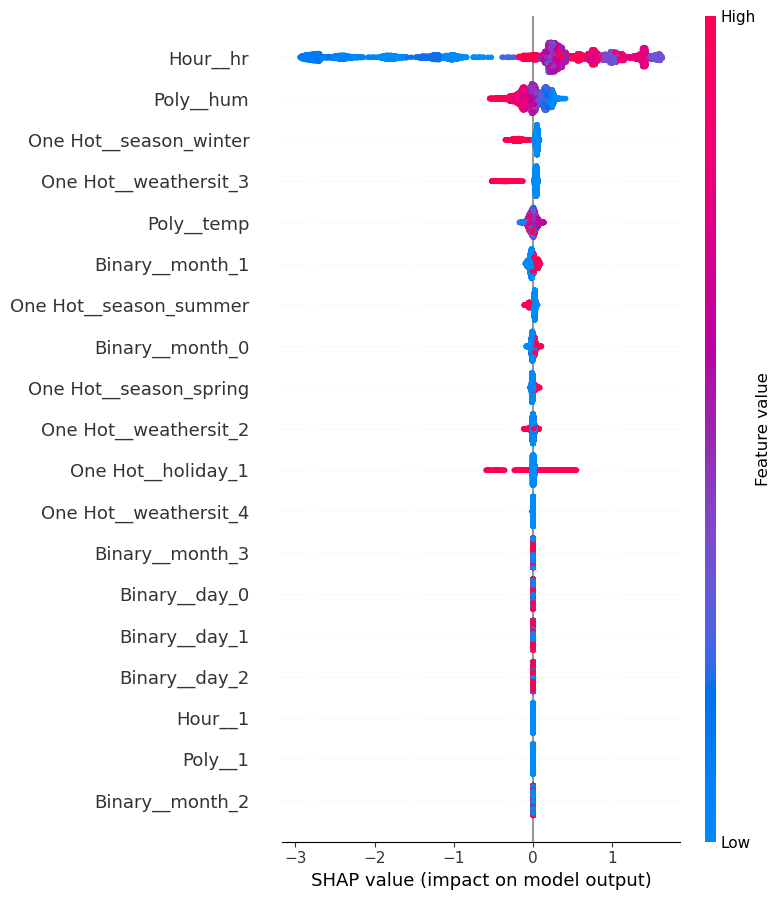

In [115]:
import shap
my_data_arr = xgb_tuning['preprocessing'].fit_transform(X_train)

# Create a SHAP explainer
explainer = shap.TreeExplainer(
    xgb_tuning['model'],
    data = my_data_arr,
    model_output='raw'
    )

# Calculate SHAP values for the training data
shap_values = explainer.shap_values(my_data_arr)

# Plot summary plot
shap.summary_plot(shap_values, my_data_arr, feature_names=xgb_tuning['preprocessing'].get_feature_names_out())

- "Hour__hr" and "Poly__hum" are the most influential features in predicting the target variable.
- Season and weather conditions also play a crucial role in the model’s predictions.
- Some binary variables contribute very little, suggesting they may be less relevant.

****
## **5. Limitations**

### **Feature Limitations**

For this model to be used,  data must follow these constraints:
| **Feature** | **Type** | **Acceptable Inputs** |
| --- | --- | --- |
| hum | Float | 0.0 to 1.0 |
| weathersit | Category | {'1', '2', '3', '4'} |
| holiday | Category | {'0', '1'} |
| season | Category | {'winter', 'spring', 'summer', 'fall'} |
| temp | Float | 0.0 to 1.0 |
| hr | Integer | 0 to 23 |
| month | Category | {'January','February',...,'December'} |
| day | Category | {'Monday','Tuesday',...,'Sunday'} |

Any input outside of these boundaries might cause inaccuracy or failure in the model


### **Target Limitations**

- The target used in this model is log-transformed (np.log1p(y)) before modeling. For example, if the target is 200 bikes, the target inputted to the model will be log1p(200)

- The prediction output of this model will also be in log scale and **must be exponentiated (np.expm1(y_pred)) to get actual values**

- Since the target is log-transformed, target values must not be a negative value

### **Model Limitations**

- Predictions below 400 are generally accurate.
- Predictions between 400 and 600 show higher variability, leading to larger errors.
- Predictions above 600 tend to be underestimated (i.e., the model predicts lower than the actual values).

****
## **6. Conclusion**

A Model for predicting the amount of bike rents has been made, using XGBoost Regressor Algorithm with the following hyperparameters:

In [128]:
best_param_df = pd.DataFrame(random_xgb.best_params_,index=random_xgb.best_params_.keys(),columns=['Best Parameters'])
best_param_df['Best Parameters'] = random_xgb.best_params_.values()
best_param_df

,Best Parameters
preprocessing__Poly__degree,1.000000
preprocessing__Hour__PolynomialFeatures__degree,1.000000
model__subsample,0.833333
model__reg_lambda,10.000000
model__reg_alpha,1.778279
model__n_estimators,652.000000
model__max_depth,7.000000
model__learning_rate,0.063368
model__colsample_bytree,0.733333


- The most influential features in this model are Hour and Humidity, with Season and Weather Conditions also playing a significant role in predictions.

- The model achieves a MAPE (Mean Absolute Percentage Error) of 0.085 for log-transformed values. When evaluated on actual values, the MAPE is 0.337, meaning the model's predictions may deviate by approximately 33.7% from the true values.

- However the inaccuracies might get bigger when the predicted values go higher above 400 bikes. The model also seems to underpredict the actual value when it reaches around 600. If the model predicts a count above 600, it may be beneficial to adjust the prediction upward by approximately 33.7% to account for underestimation.

****
## **7. Recommendation**

A few Recommendations to improve the model:

- Experiment on Training the Model with Actual Values or Alternative techniques such as Box-Cox Tranformation or quantile regression instead og log-transformation to handle skewness

- Since the model tends to underpredict at higher values, a post-prediction adjustment could be applied, such as multiplying predictions above a threshold (e.g., 600) by a corrective factor

- Introduction of new features and existing data would be beneficial to the model. For example, more data collected outside of 2011-2012 would enable us to consider the year column as a feature and help the model consider any fluctuating trends over the years. Things like station locations or distance to public spaces can be especially helpful. 

****
**Saving the Model**

In [ ]:
# import joblib

# # Save the entire pipeline/model
# joblib.dump(random_xgb, "bike_demand_xgb.pkl")

# # Load the saved model
# loaded_model = joblib.load("bike_demand_xgb.pkl")